In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from matplotlib.pyplot import title, ylabel

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option("display.float_format", "{:.3f}".format)

df = pd.read_csv(Path("../data/credit_risk_dataset.csv"))
print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.000,PERSONAL,D,35000,16.020,1,0.590,Y,3
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4


In [2]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000,32581.000,31686.000,32581.000,29465.000,32581.000,32581.000,32581.000
mean,27.735,66074.848,4.790,9589.371,11.012,0.218,0.170,5.804
std,6.348,61983.119,4.143,6322.087,3.240,0.413,0.107,4.055
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000
25%,23.000,38500.000,2.000,5000.000,7.900,0.000,0.090,3.000
50%,26.000,55000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,79200.000,7.000,12200.000,13.470,0.000,0.230,8.000
max,144.000,6000000.000,123.000,35000.000,23.220,1.000,0.830,30.000


In [3]:
print("===Аномалии данных===")
print(f"Максимальный возраст: {df['person_age'].max()} - явная ошибка при вводе данных")
print(f"Строк с возрастом > 75: {(df['person_age'] > 75).sum()}")

print(f"\nМаксимальный стаж: {df['person_emp_length'].max()} - явная ошибка")
print(f"Строк со стажем > 50: {(df['person_emp_length'] > 50).sum()}")

print(f"\nМаксимальный доход: {df['person_income'].max():,}")
print(f"99-й перцентиль дохода: {df['person_income'].quantile(0.99):,.0f}")
print(f"Строк с доходом > 500.000: {(df['person_income'] > 500_000).sum()}")

print(f"\nСредний возраст: {df['person_age'].mean():.1f}")
print(f"Медианный возраст: {df['person_age'].median():.1f}")

===Аномалии данных===
Максимальный возраст: 144 - явная ошибка при вводе данных
Строк с возрастом > 75: 10

Максимальный стаж: 123.0 - явная ошибка
Строк со стажем > 50: 2

Максимальный доход: 6,000,000
99-й перцентиль дохода: 225,200
Строк с доходом > 500.000: 53

Средний возраст: 27.7
Медианный возраст: 26.0


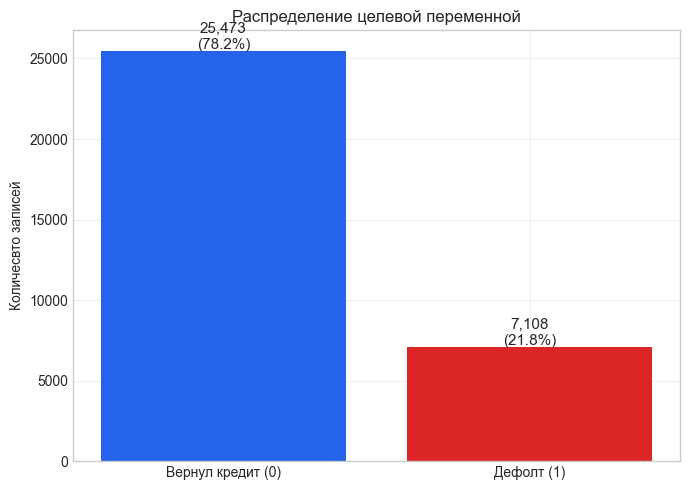

In [4]:
fig, ax =plt.subplots(figsize=(7,5))

counts = df['loan_status'].value_counts()
bars = ax.bar(['Вернул кредит (0)', 'Дефолт (1)'],
              counts.values,
              color=['#2563EB', '#DC2626'])

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=11)

ax.set(title='Распределение целевой переменной',
       ylabel='Количесвто записей')
plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150)
plt.show()

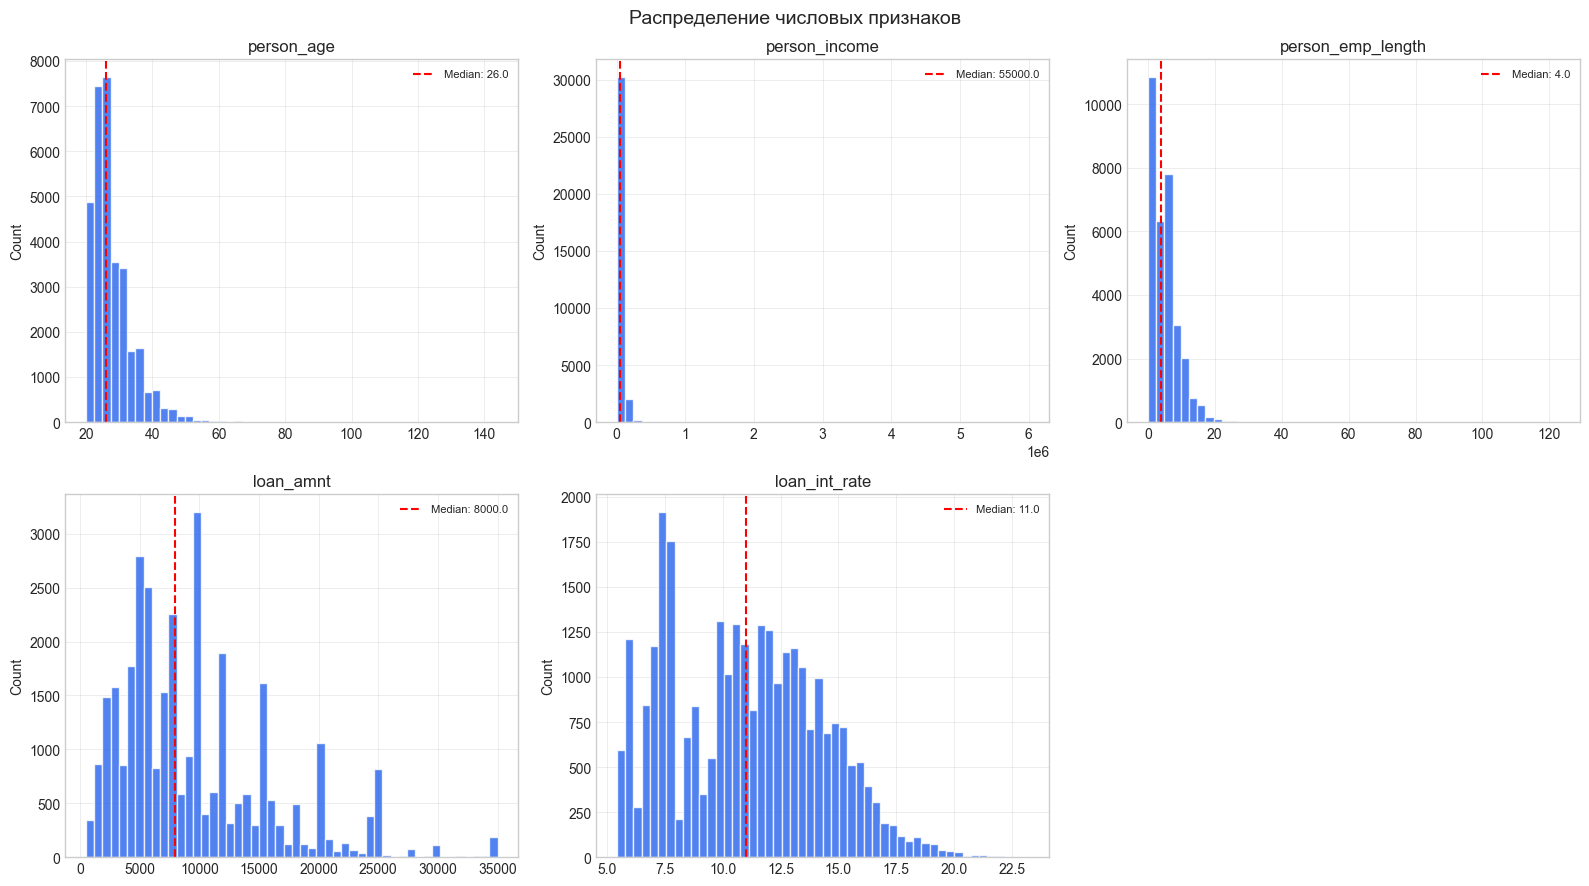

In [6]:
num_cols =['person_age', 'person_income', 'person_emp_length',
           'loan_amnt', 'loan_int_rate']
fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50,
                 color='#2563EB', edgecolor='white', alpha=0.8)
    axes[i].set(title=col, ylabel='Count')
    axes[i].axvline(df[col].median(), color='red',
                    linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Распределение числовых признаков', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/02_numeric_distribution.png', dpi=150)
plt.show()

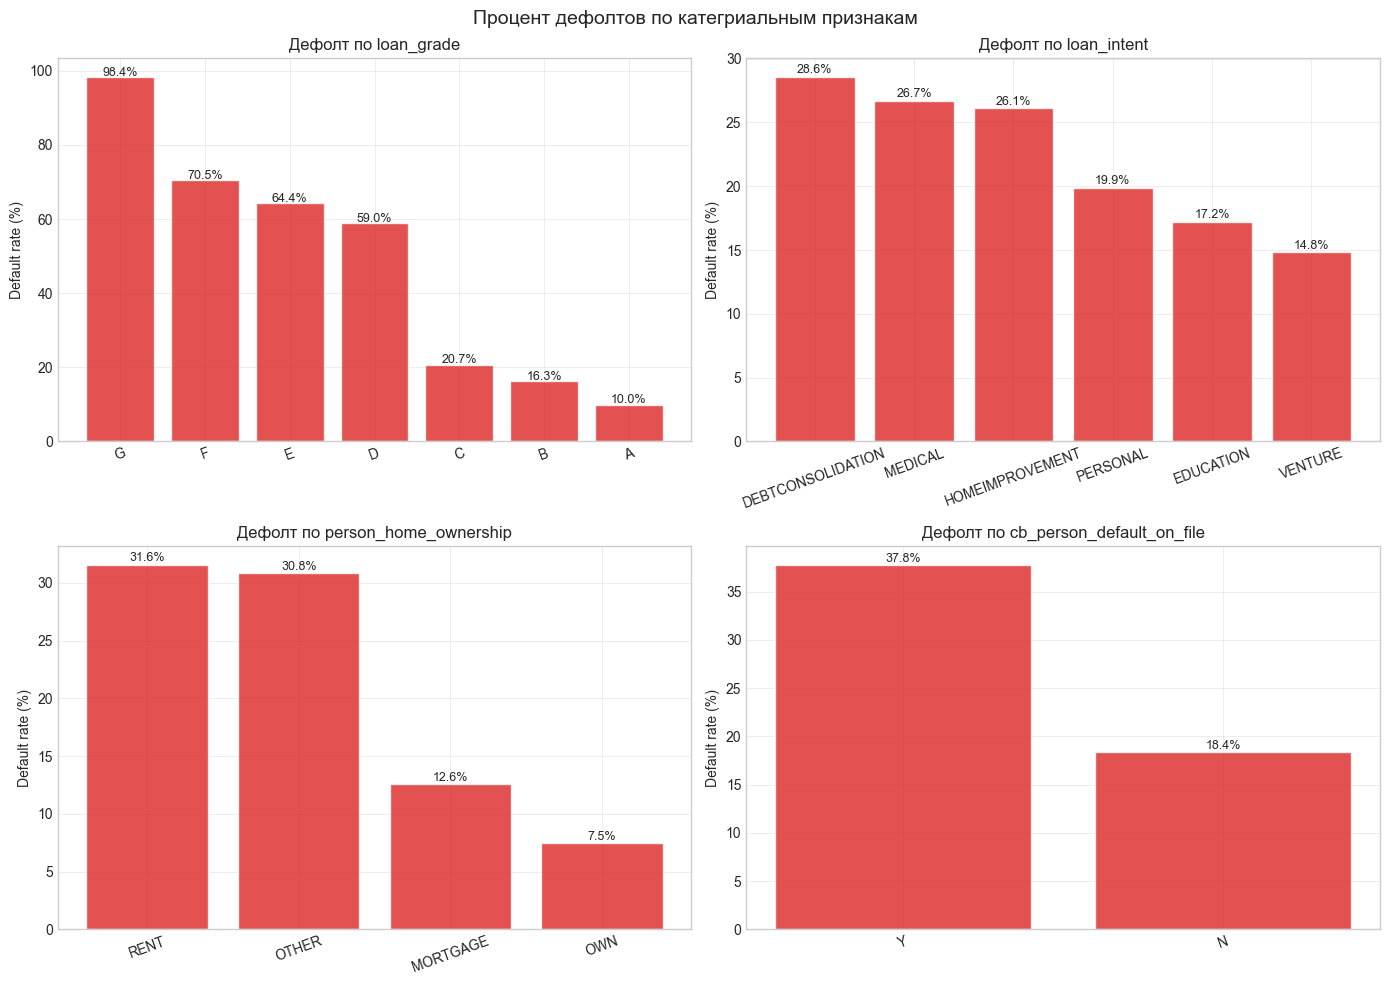

In [7]:
cat_cols =['loan_grade', 'loan_intent',
           'person_home_ownership', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes =axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = (df.groupby(col)['loan_status']
                    .mean()
                    .sort_values(ascending=False)
                    .reset_index())

    bars = axes[i].bar(default_rate[col],
                       default_rate['loan_status'] * 100,
                       color='#DC2626', alpha=0.8, edgecolor='white')

    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.3,
                     f"{bar.get_height():.1f}%",
                     ha='center', fontsize=9)

    axes[i].set(title=f"Дефолт по {col}", ylabel="Default rate (%)")
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle("Процент дефолтов по категриальным признакам", fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/03_categorical_default_rates.png', dpi=150)
plt.show()

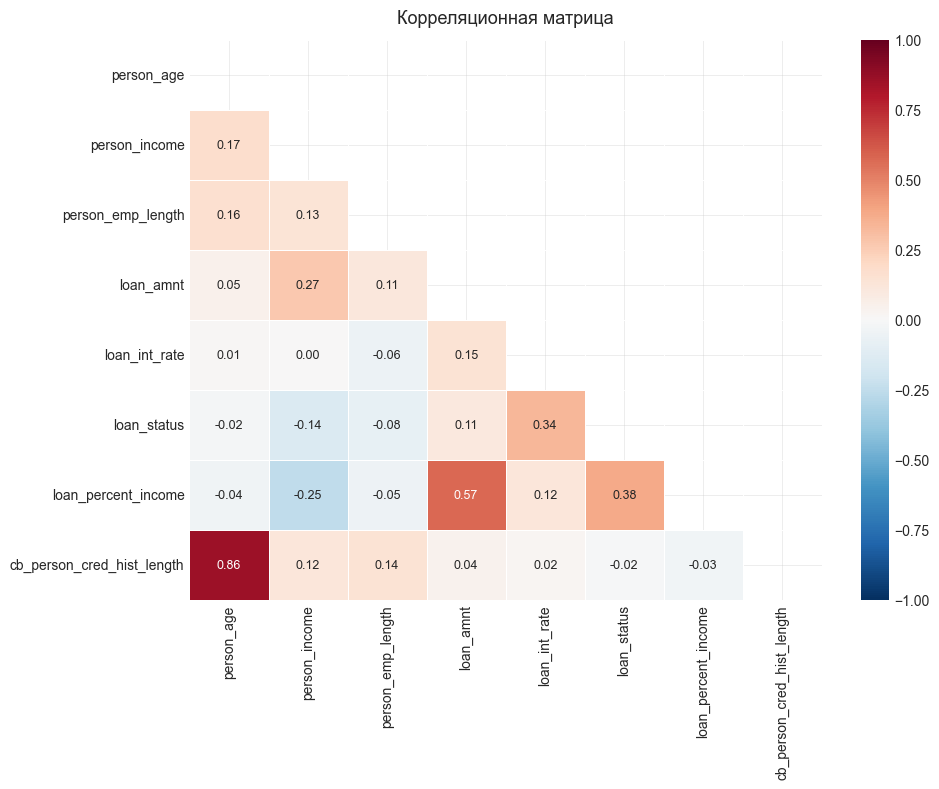

In [9]:
fig, ax = plt.subplots(figsize=(10,8))

num_df = df.select_dtypes(include='number')
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={"size": 9})

ax.set_title("Корреляционная матрица", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/figures/04_correlation_matrix.png', dpi=150)
plt.show()

## Ключевые выводы EDA

### Качество данных
- Выбросы в 'person_age' (max 144) и 'person_emp_length' (max 123) - ошибки ввода, удалить обрезать
- Пропуски в 'loan_int_rate' (9,6%) и 'person_emp_length' (2,7%) - заполнить медианной
- 53 записи с доходом > 500k - обрезать по 99-му перцентилю

### Целевая переменная
- Дисбаланс классов: 78,2% / 21,8% - нужен class_weight="balanced"

### Ключевые предикторы
- 'loan_grade' - главный предиктор, дефолт от 10% (A) до 96% (G)
- 'loan)int_rate' и 'loan_percent_income' - наибольшая корреляция с таргетом
- 'cb_person_default_on_file=Y' - удваивает вероятности дефолта

### Feature Engineering (план)
- 'log_income' - логарифм дохода, убрать правый скос
- 'debt_to_income' - сумма кредита / доход
- 'grade_num' - порядковый номер грейда (A=1, B=2, C=3 и тд)
- 'emp_income_interaction' - стаж * логарифм дохода

### Мультиколлинеарность
- 'person_age' и 'cb_person_cred_hist_length' коррелируют 0,86 - для бустинга не кристично